# Round 2 Pepper Root Prices
This notebook loads the round 2 price files from `datasets/round2`, filters for `INTARIAN_PEPPER_ROOT`, and plots its round 2 mid prices.

In [18]:
# Import Libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

#plt.style.use('seaborn-darkgrid')

In [19]:
# Load Dataset
round2_dir = Path('../datasets/round2')
price_files = sorted(round2_dir.glob('prices_round_2_day_*.csv'))

price_dfs = []
for path in price_files:
    df = pd.read_csv(path, sep=';')
    price_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True)
print(f'Loaded {len(price_files)} files with {len(prices)} rows total.')
prices.head()

Loaded 3 files with 60000 rows total.


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
1,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0
2,-1,100,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0


In [20]:
# Filter for Pepper Root
#pepper_root = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
pepper_root = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
print(f'Filtered pepper root rows: {len(pepper_root)}')
pepper_root.head()

Filtered pepper root rows: 30000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
5,-1,200,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,11006.0,9.0,11009.0,22.0,NaN,NaN,11006.0,0.0
6,-1,300,INTARIAN_PEPPER_ROOT,10994.0,8.0,NaN,NaN,NaN,NaN,11009.0,23.0,NaN,NaN,NaN,NaN,11001.5,0.0
8,-1,400,INTARIAN_PEPPER_ROOT,10994.0,10.0,10992.0,15.0,NaN,NaN,11006.0,10.0,11009.0,15.0,NaN,NaN,11000.0,0.0


In [21]:
# Extract Round 2 Prices
pepper_root['round2_day'] = pepper_root['day'].astype(int)
pepper_root = pepper_root.sort_values(['round2_day', 'timestamp'])

invalid_mid_price = pepper_root['mid_price'] <= 0
print(f'Removing {invalid_mid_price.sum()} rows with non-positive mid_price')
pepper_root = pepper_root[~invalid_mid_price].copy()
pepper_root[['round2_day', 'timestamp', 'mid_price']].head()

Removing 47 rows with non-positive mid_price


,round2_day,timestamp,mid_price
0,-1,0,11001.5
3,-1,100,11000.0
5,-1,200,11006.0
6,-1,300,11001.5
8,-1,400,11000.0


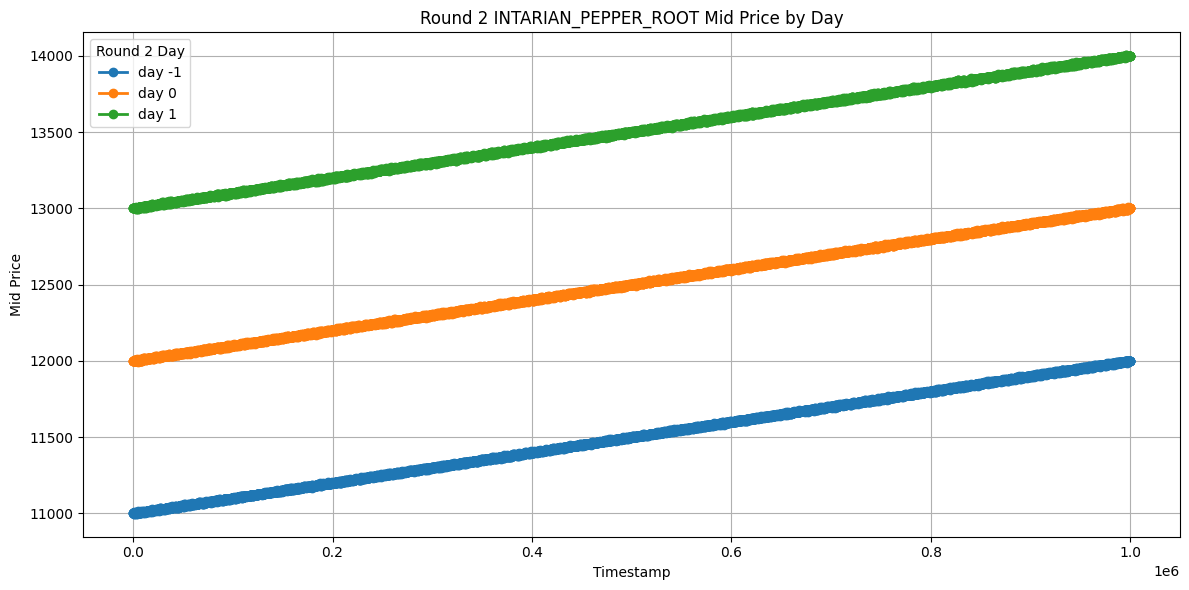

In [22]:
# Plot Round 2 Prices
plt.figure(figsize=(12, 6))
for day, group in pepper_root.groupby('round2_day'):
    plt.plot(group['timestamp'], group['mid_price'], marker='o', linewidth=2, label=f'day {day}')

#plt.title('Round 2 ASH_COATED_OSMIUM Mid Price by Day')
plt.title('Round 2 INTARIAN_PEPPER_ROOT Mid Price by Day')
plt.xlabel('Timestamp')
plt.ylabel('Mid Price')
plt.legend(title='Round 2 Day')
plt.grid(True)
plt.tight_layout()
plt.show()